# Phase 2.4: Perbandingan GC vs PDC (Semua Band)

**Tujuan:**  
Membandingkan secara statistik metrik konektivitas antara **GC** dan seluruh
**6 band PDC** (Delta, Theta, Alpha, Beta, Gamma, Broadband) untuk mengetahui
metode mana yang paling diskriminatif dalam memisahkan kelas emosi.

**Analisis:**
1. Statistik Deskriptif per metode
2. Visualisasi Side-by-Side Boxplot (semua metode)
3. Uji Inferensial lengkap per metode (Shapiro→Levene→ANOVA/Kruskal→Effect Size)
4. Tabel Perbandingan pemenang per metrik
5. Bar Chart & Heatmap Signifikansi
6. Ringkasan pemenang GC vs PDC

---

In [9]:
# ============================================================
# SEL INI: IMPORT LIBRARY & KONFIGURASI GLOBAL
# ------------------------------------------------------------
# Memuat semua library, mendefinisikan path, dan memuat 7 CSV
# (GC + 6 band PDC) dari Phase 1. Prefix kolom di-strip agar
# nama metrik menjadi generik (misal gc_mean_out_degree -> mean_out_degree).
# PENTING: CLASS_COL = 'class_label' (teks) WAJIB dipakai
#          untuk filter & plot, bukan 'class' (angka 0/1/2).
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.facecolor'] = 'white'

PHASE1_DIR = Path(r'D:\Skripsi\new_data\phase_1_data_structuring\csv')
OUTPUT_DIR = Path(r'D:\Skripsi\new_data\phase_2_statistics\2.4_gc_vs_pdc_comparison\output')
FIG_DIR    = Path(r'D:\Skripsi\new_data\phase_2_statistics\2.4_gc_vs_pdc_comparison\figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# FIX: Konvensi kolom — selalu gunakan CLASS_COL bukan 'class'
CLASS_COL = 'class_label'
EMOTIONS  = ['negative', 'neutral', 'positive']
PALETTE   = {'negative': '#e74c3c', 'neutral': '#3498db', 'positive': '#2ecc71'}

MEAN_COLS = ['mean_out_degree','mean_in_degree','mean_total_degree',
             'mean_out_strength','mean_in_strength','mean_total_strength']
SHORT = {
    'mean_out_degree':'Out Deg', 'mean_in_degree':'In Deg',
    'mean_total_degree':'Total Deg', 'mean_out_strength':'Out Str',
    'mean_in_strength':'In Str', 'mean_total_strength':'Total Str',
}

DATASETS = {
    'GC'           : PHASE1_DIR / 'cleaned_graph_metrics_gc.csv',
    'PDC Delta'    : PHASE1_DIR / 'cleaned_graph_metrics_pdc_delta.csv',
    'PDC Theta'    : PHASE1_DIR / 'cleaned_graph_metrics_pdc_theta.csv',
    'PDC Alpha'    : PHASE1_DIR / 'cleaned_graph_metrics_pdc_alpha.csv',
    'PDC Beta'     : PHASE1_DIR / 'cleaned_graph_metrics_pdc_beta.csv',
    'PDC Gamma'    : PHASE1_DIR / 'cleaned_graph_metrics_pdc_gamma.csv',
    'PDC Broadband': PHASE1_DIR / 'cleaned_graph_metrics_pdc_broadband.csv',
}

data = {}
for name, csv_path in DATASETS.items():
    if not csv_path.exists():
        print(f'  [SKIP] {name}: tidak ditemukan')
        continue
    df = pd.read_csv(csv_path)
    prefix = 'gc' if name == 'GC' else f"pdc_{name.lower().split()[-1]}"
    df = df.rename(columns={
        c: c.replace(f'{prefix}_','',1) for c in df.columns if c.startswith(f'{prefix}_')
    })
    data[name] = df
    print(f'  Loaded {name}: {df.shape} | {CLASS_COL}: {sorted(df[CLASS_COL].unique())}')

print(f'\nOutput : {OUTPUT_DIR}')
print(f'Figures: {FIG_DIR}')
print(f'Metode : {list(data.keys())}')


  Loaded GC: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Delta: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Theta: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Alpha: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Beta: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Gamma: (675, 4047) | class_label: ['negative', 'neutral', 'positive']
  Loaded PDC Broadband: (675, 4047) | class_label: ['negative', 'neutral', 'positive']

Output : D:\Skripsi\new_data\phase_2_statistics\2.4_gc_vs_pdc_comparison\output
Figures: D:\Skripsi\new_data\phase_2_statistics\2.4_gc_vs_pdc_comparison\figures
Metode : ['GC', 'PDC Delta', 'PDC Theta', 'PDC Alpha', 'PDC Beta', 'PDC Gamma', 'PDC Broadband']


---
## 1. Statistik Deskriptif Per Metode

Mean, Std, Median, IQR untuk setiap metrik per kelas emosi, dikelompokkan per metode.

In [10]:
# ============================================================
# SEL INI: STATISTIK DESKRIPTIF PER METODE
# ------------------------------------------------------------
# Menghitung Mean, Std, Median, Q1, Q3, IQR untuk setiap
# kombinasi (metode x kelas emosi x metrik).
# FIX: Filter emosi menggunakan CLASS_COL ('class_label'),
#      bukan 'class' (numerik 0/1/2) yang menghasilkan 0 baris.
# FIX: Lewati metrik zero-variance (std=0) dengan keterangan.
# Output: descriptive_stats_{method}.csv
# ============================================================
def descriptive_stats(df, method_name):
    rows = []
    for col in MEAN_COLS:
        is_zero_var = df[col].dropna().std() < 1e-10
        for emo in EMOTIONS:
            # FIX: gunakan CLASS_COL ('class_label')
            subset = df[df[CLASS_COL] == emo][col].dropna()
            rows.append({
                'metric'  : SHORT[col],
                'emotion' : emo,
                'n'       : len(subset),
                'mean'    : round(subset.mean(), 4) if len(subset) > 0 else np.nan,
                'std'     : round(subset.std(),  4) if len(subset) > 0 else np.nan,
                'median'  : round(subset.median(),4) if len(subset) > 0 else np.nan,
                'iqr'     : round(subset.quantile(0.75)-subset.quantile(0.25),4) if len(subset)>0 else np.nan,
                'min'     : round(subset.min(), 4) if len(subset) > 0 else np.nan,
                'max'     : round(subset.max(), 4) if len(subset) > 0 else np.nan,
                'note'    : 'Zero Variance' if is_zero_var else '',
            })
    result = pd.DataFrame(rows)
    result.to_csv(OUTPUT_DIR / f'descriptive_{method_name.lower().replace(" ","_")}.csv', index=False)
    return result

all_desc = {}
for name, df in data.items():
    desc = all_desc[name] = descriptive_stats(df, name)
    print(f'\n{"="*65}')
    print(f'  {name} - Descriptive Statistics')
    print(f'{"="*65}')
    print(f'  {"Metric":<12} {"Emotion":<10} {"Mean":>10} {"Std":>10} {"Median":>10} {"IQR":>10}')
    print('  '+'-'*55)
    for _, row in desc.iterrows():
        note = f" [{row['note']}]" if row['note'] else ''
        m    = f"{row['mean']:.4f}" if not np.isnan(row['mean']) else 'N/A'
        s    = f"{row['std']:.4f}"  if not np.isnan(row['std'])  else 'N/A'
        med  = f"{row['median']:.4f}" if not np.isnan(row['median']) else 'N/A'
        iqr  = f"{row['iqr']:.4f}"  if not np.isnan(row['iqr'])  else 'N/A'
        print(f'  {row["metric"]:<12} {row["emotion"]:<10} {m:>10} {s:>10} {med:>10} {iqr:>10}{note}')
    print(f'  -> Saved: descriptive_{name.lower().replace(" ","_")}.csv')



  GC - Descriptive Statistics
  Metric       Emotion          Mean        Std     Median        IQR
  -------------------------------------------------------
  Out Deg      negative       6.3365     3.3538     6.1129     0.0000
  Out Deg      neutral        6.3390     3.3914     6.1129     0.0000
  Out Deg      positive       6.3388     3.3882     6.1129     0.0000
  In Deg       negative       6.3365     3.3538     6.1129     0.0000
  In Deg       neutral        6.3390     3.3914     6.1129     0.0000
  In Deg       positive       6.3388     3.3882     6.1129     0.0000
  Total Deg    negative      12.6730     6.7075    12.2258     0.0000
  Total Deg    neutral       12.6780     6.7828    12.2258     0.0000
  Total Deg    positive      12.6776     6.7763    12.2258     0.0000
  Out Str      negative    2114.2545   901.8650  1952.4567  1106.6387
  Out Str      neutral     2239.6123   920.4099  2063.7065   946.2852
  Out Str      positive    2499.9037   790.6783  2474.2160   996.8020
 

---
## 2. Visualisasi: Side-by-Side Boxplot

Setiap gambar = 1 metrik dengan subplot per metode (GC + 6 band PDC),
menunjukkan distribusi per kelas emosi untuk perbandingan langsung.


>>> Out Deg
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.4_gc_vs_pdc_comparison\figures\boxplot_mean_out_degree.png


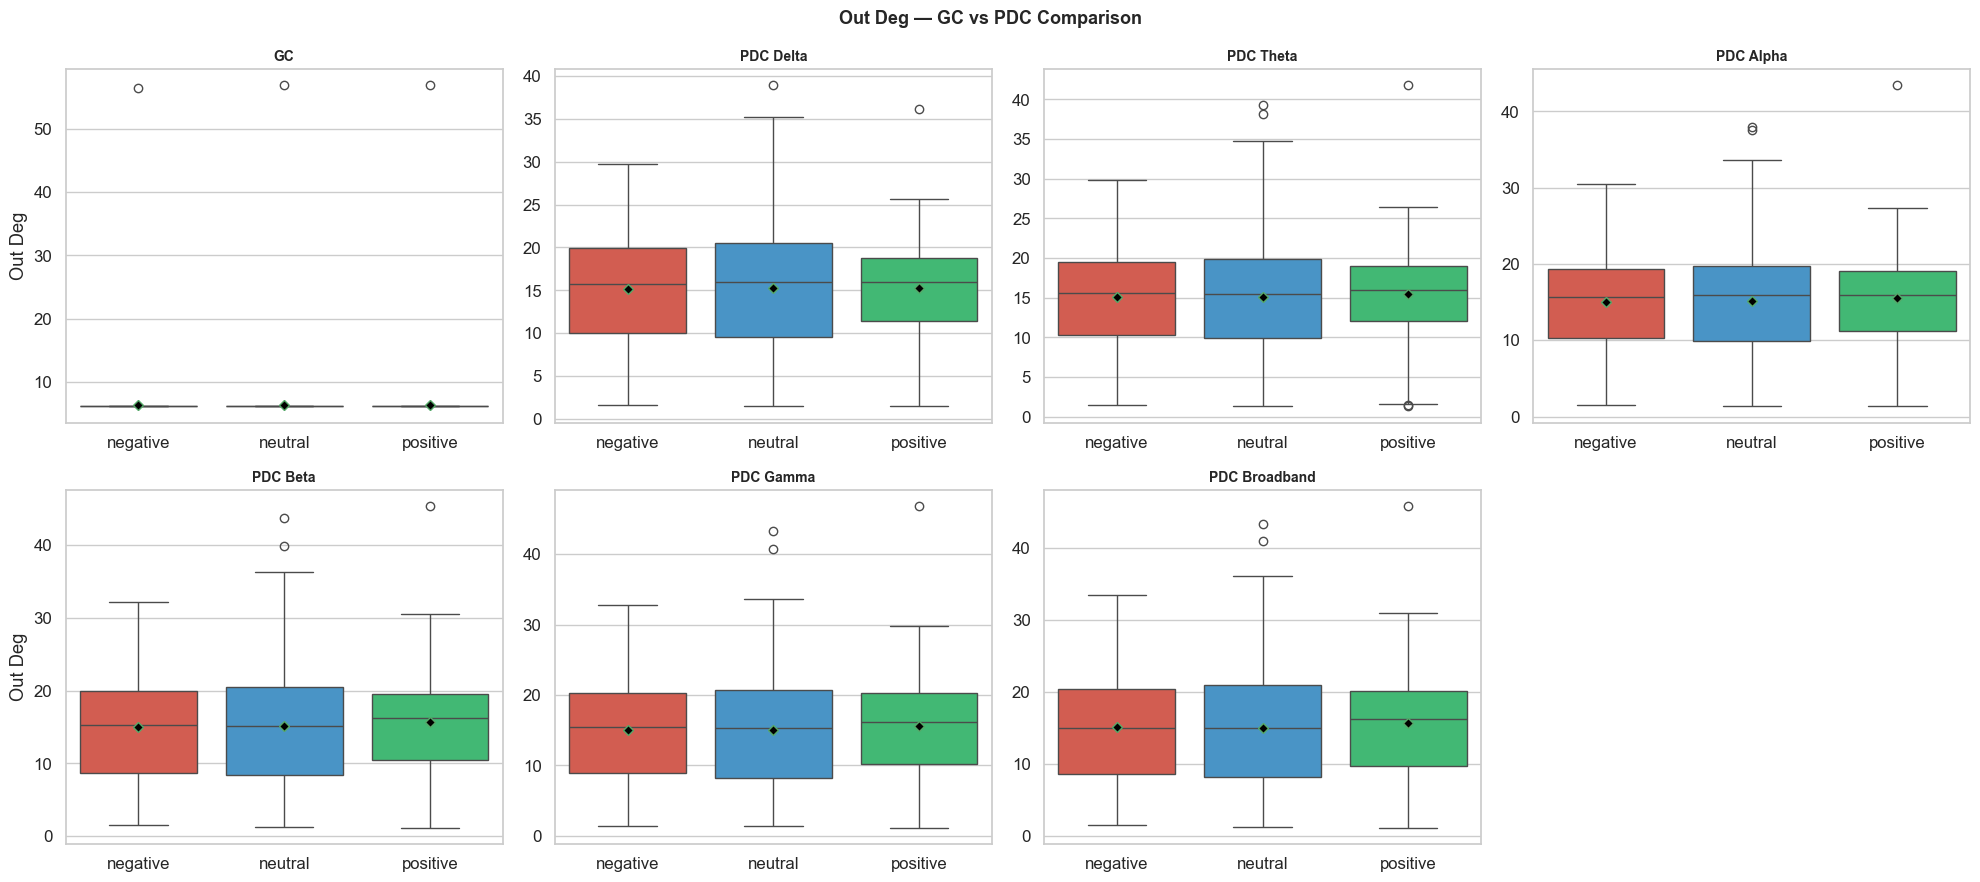


>>> In Deg
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.4_gc_vs_pdc_comparison\figures\boxplot_mean_in_degree.png


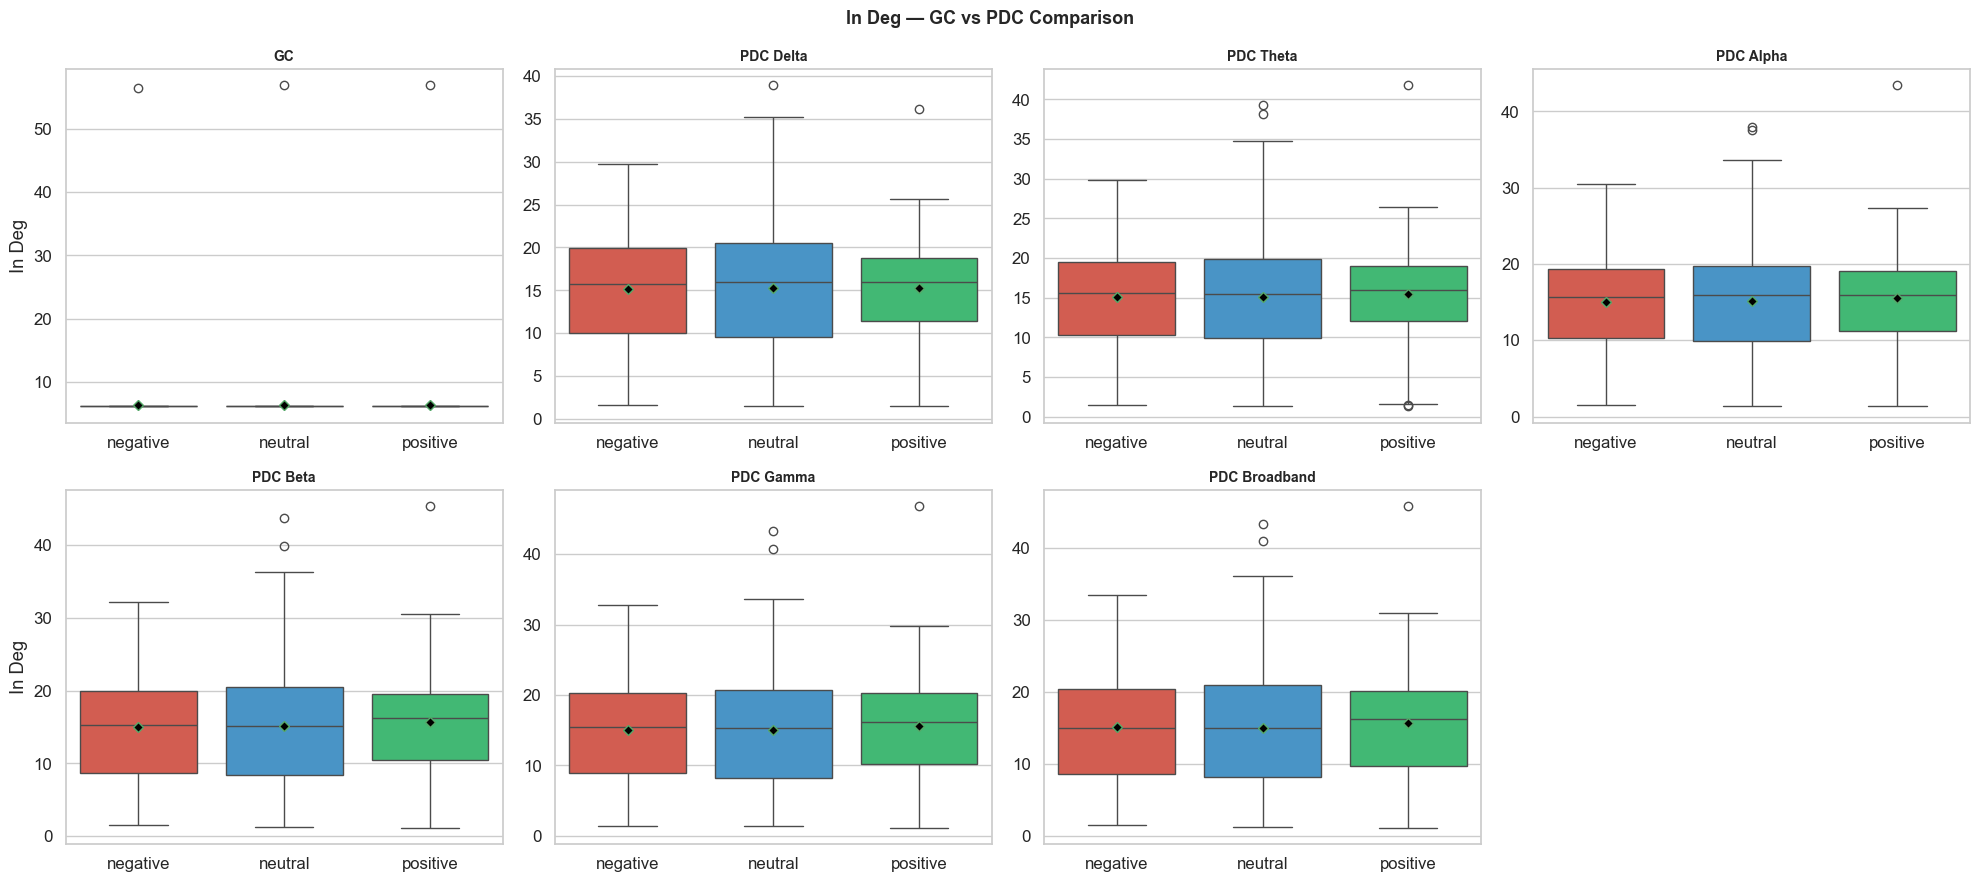


>>> Total Deg
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.4_gc_vs_pdc_comparison\figures\boxplot_mean_total_degree.png


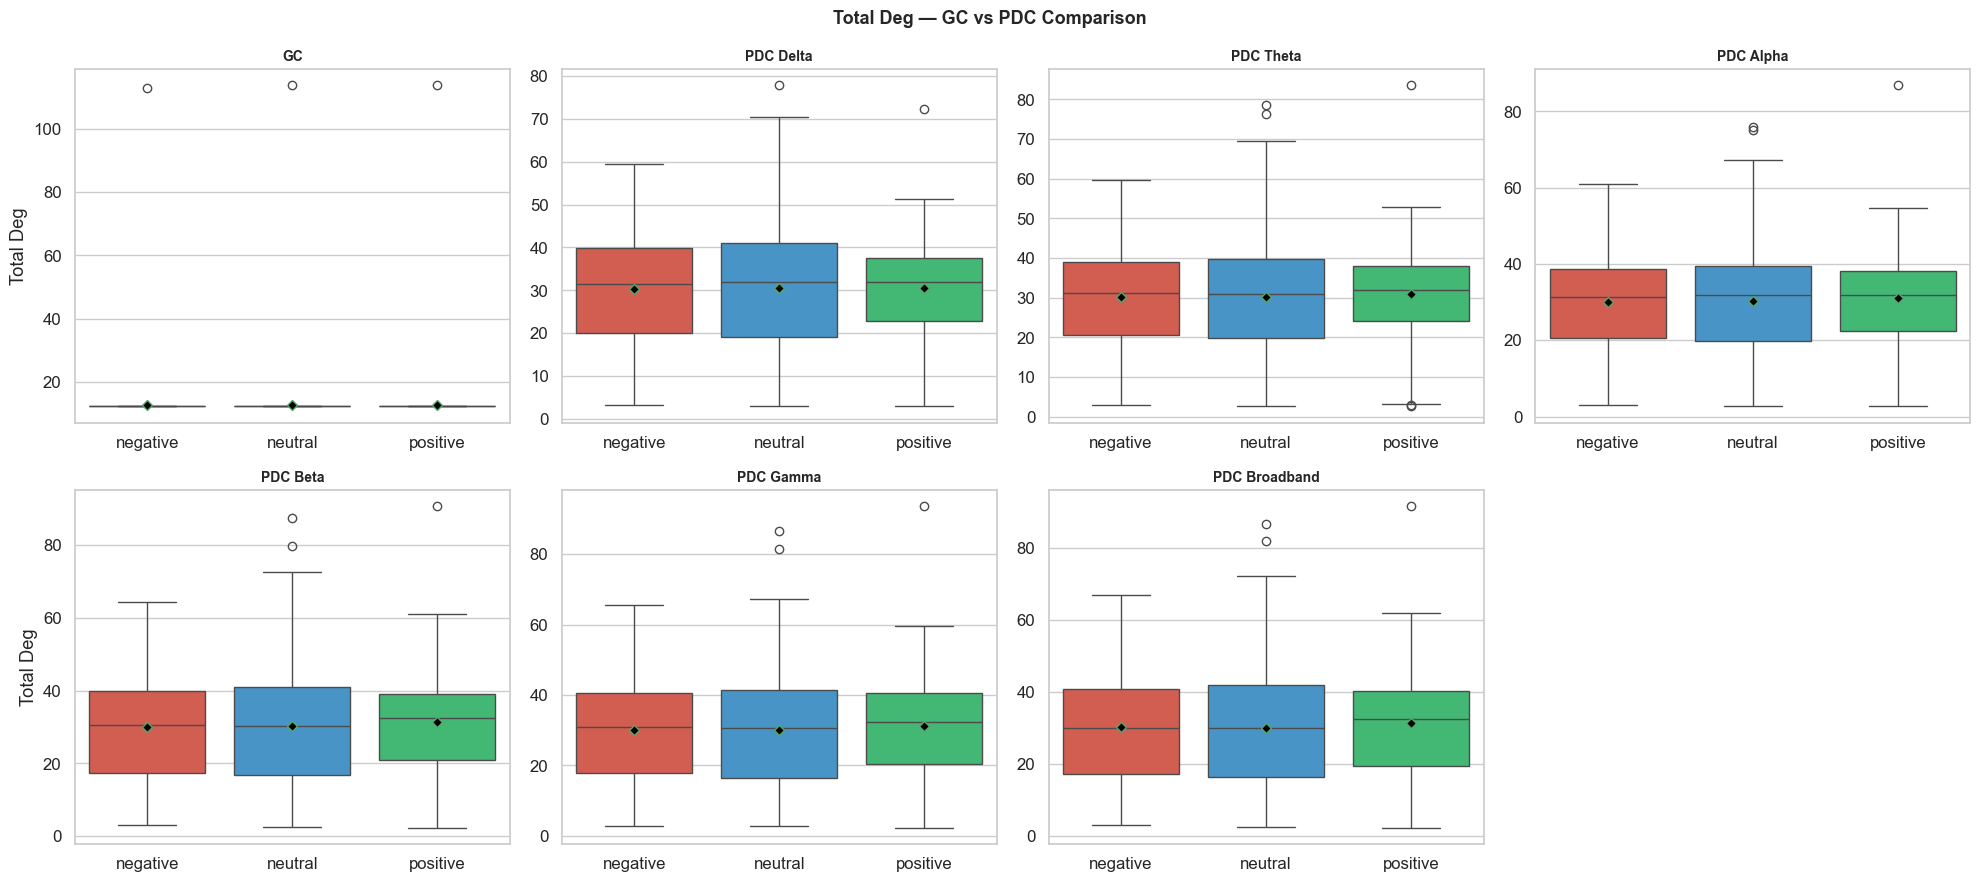


>>> Out Str
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.4_gc_vs_pdc_comparison\figures\boxplot_mean_out_strength.png


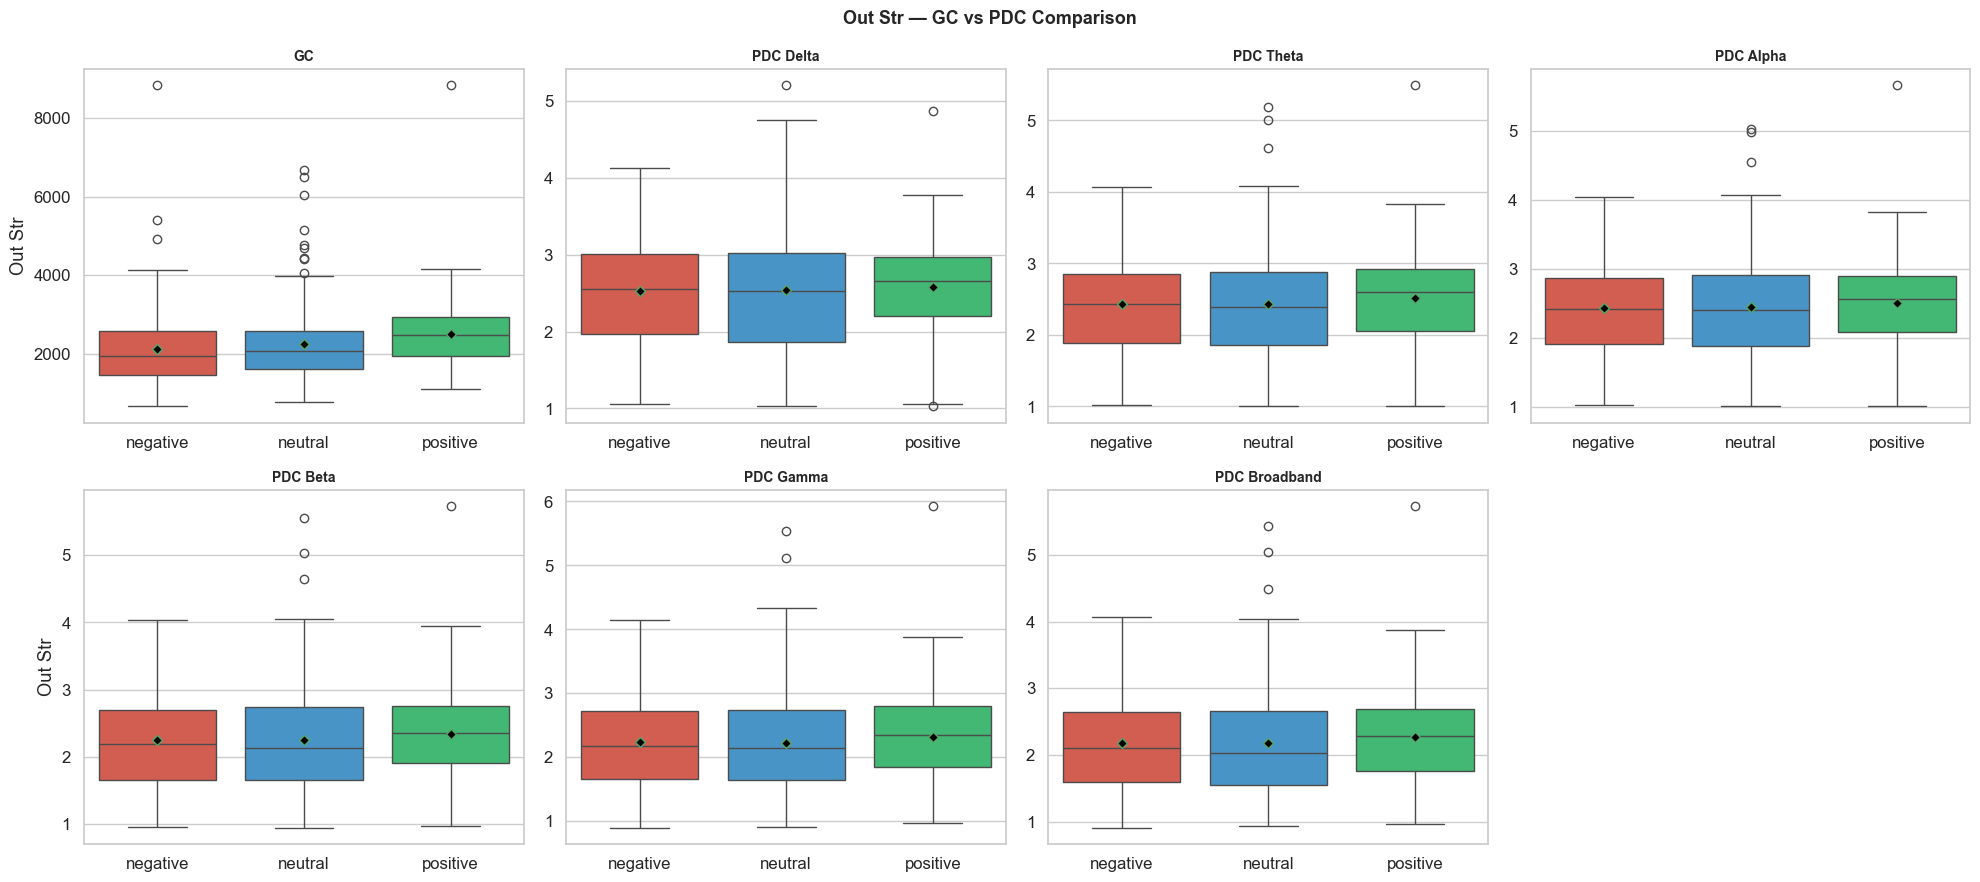


>>> In Str
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.4_gc_vs_pdc_comparison\figures\boxplot_mean_in_strength.png


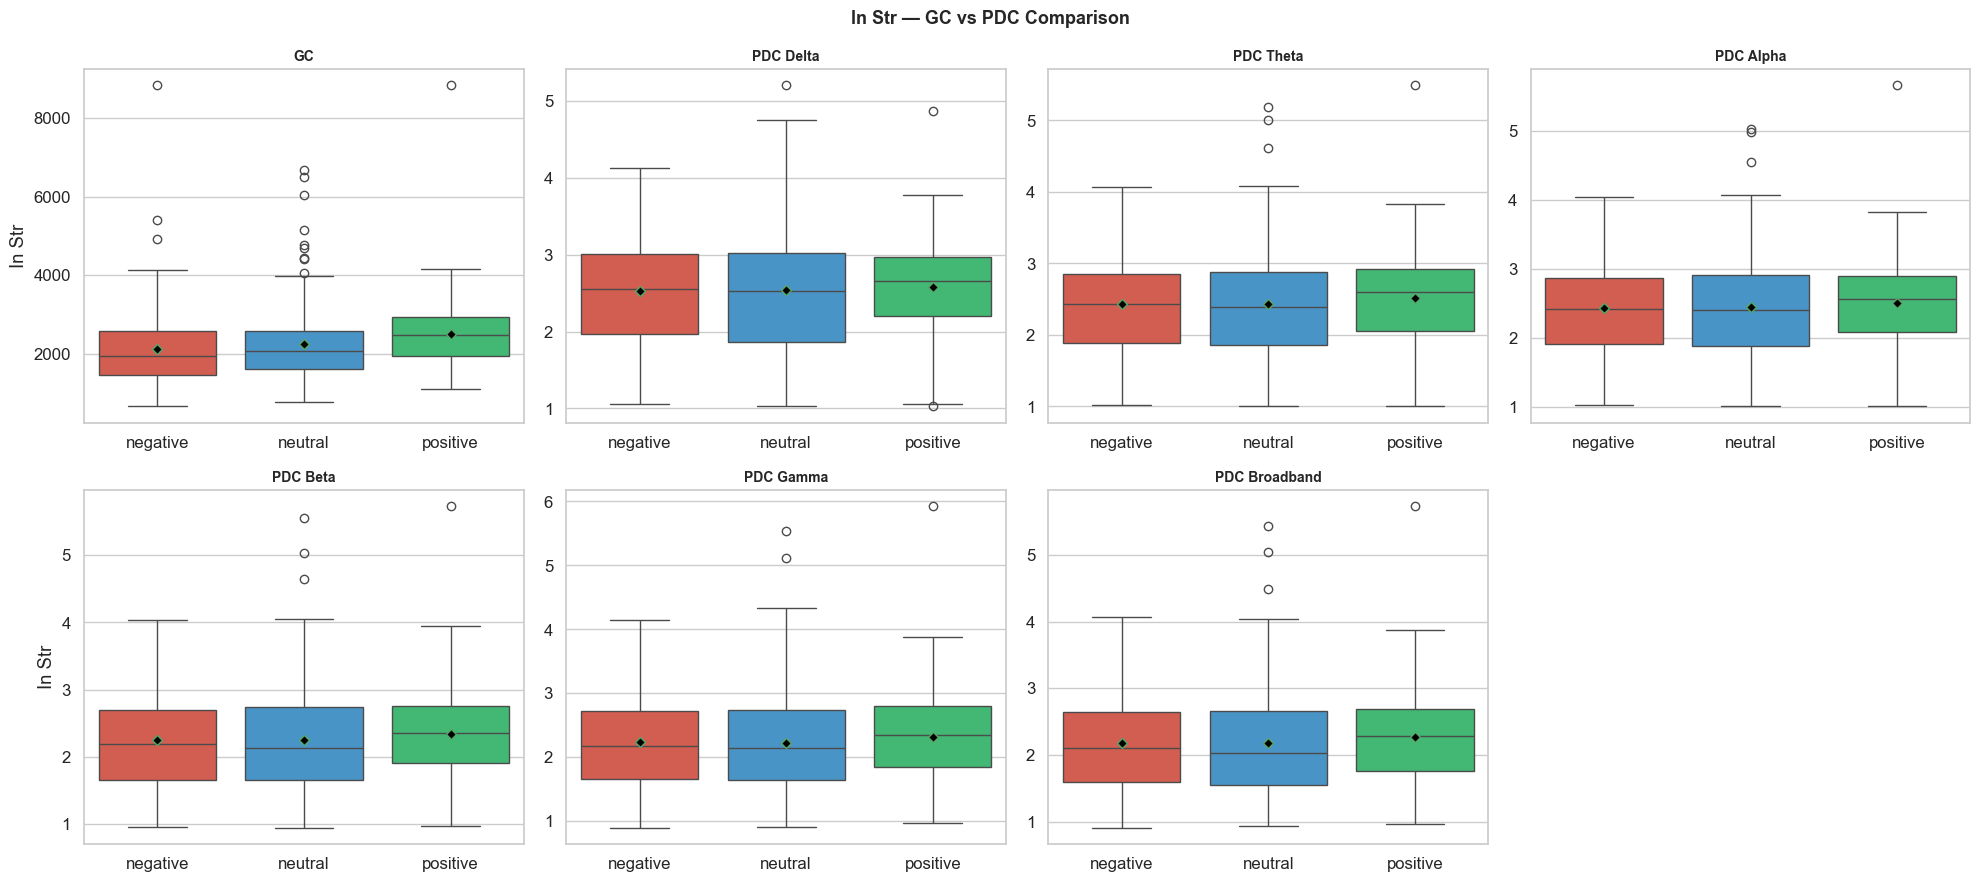


>>> Total Str
  Saved: D:\Skripsi\new_data\phase_2_statistics\2.4_gc_vs_pdc_comparison\figures\boxplot_mean_total_strength.png


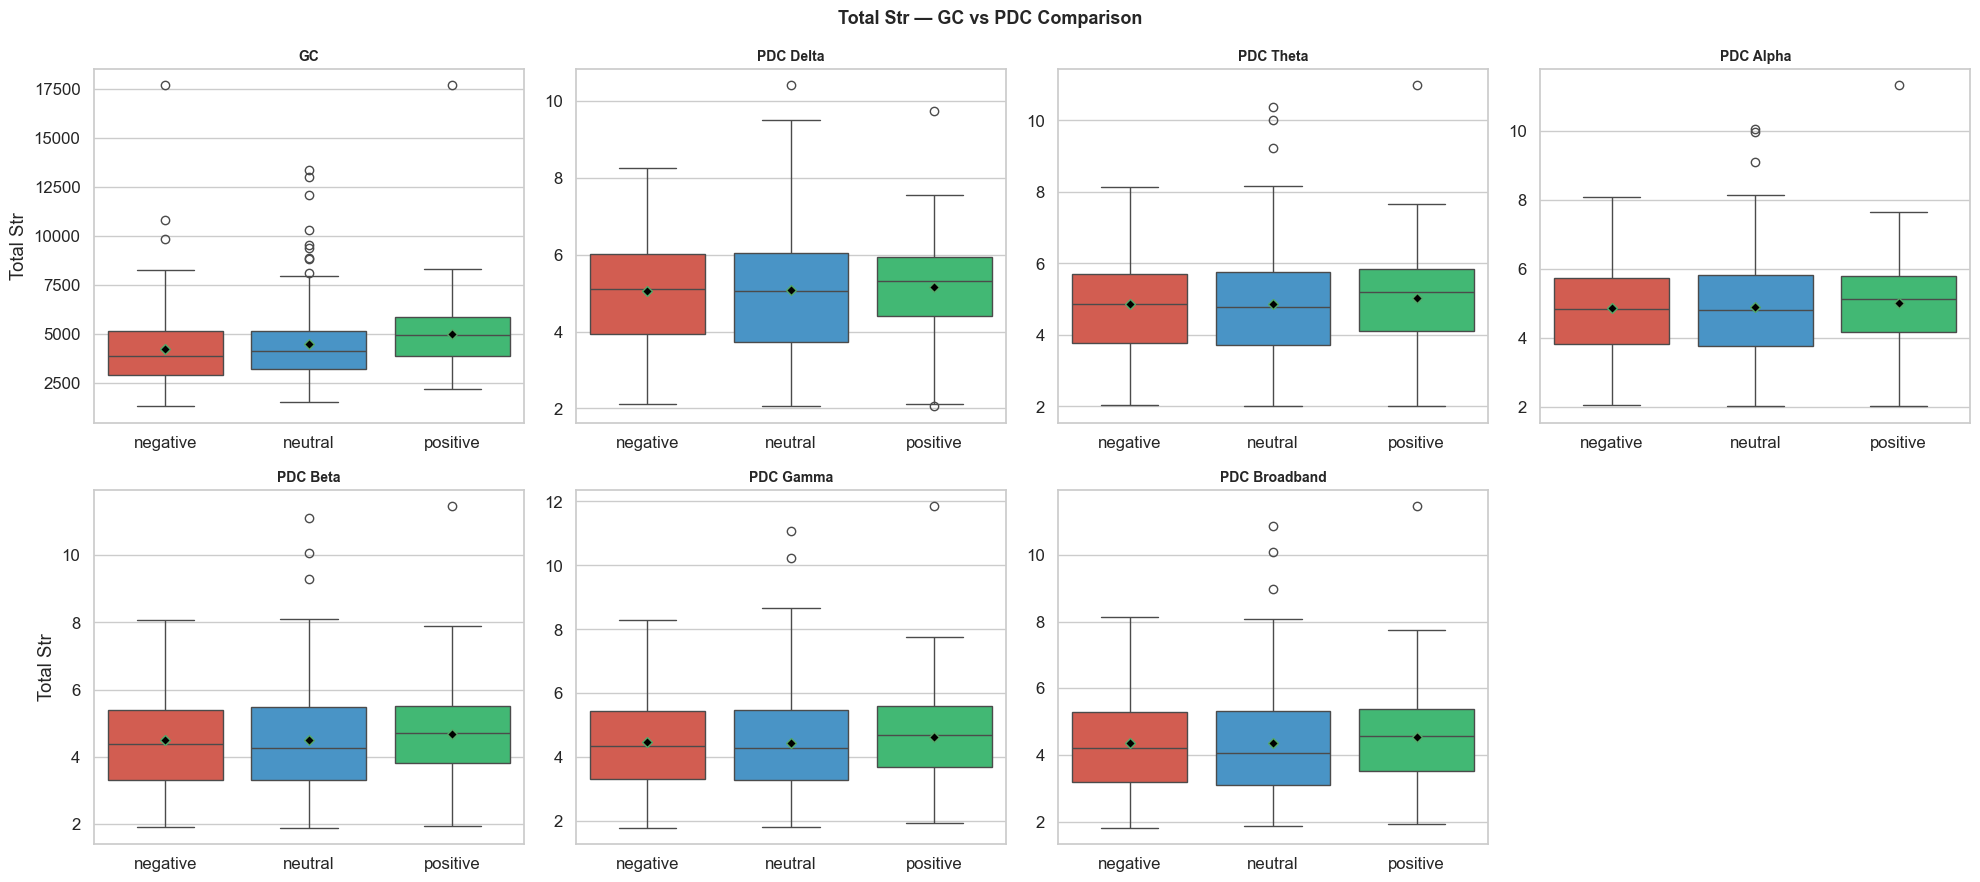

In [11]:
# ============================================================
# SEL INI: SIDE-BY-SIDE BOXPLOT SEMUA METODE
# ------------------------------------------------------------
# Membuat 1 gambar per metrik (6 gambar total), dengan setiap
# subplot menampilkan distribusi 3 emosi untuk satu metode.
# FIX 1: Menggunakan CLASS_COL ('class_label') bukan 'class'
#         agar sumbu-X menampilkan teks emosi, bukan angka.
# FIX 2: Jumlah subplot DINAMIS sesuai jumlah metode aktual
#         (sebelumnya hard-coded 4, sekarang mendukung 7+).
# FIX 3: Lewati metrik zero-variance (PDC Degree) agar
#         tidak menghasilkan subplot kosong yang menyesatkan.
# Output: boxplot_{metric}.png
# ============================================================
def plot_side_by_side(metric_col, metric_label):
    n  = len(data)
    # FIX: subplot dinamis, maksimal 4 per baris
    nc = min(4, n)
    nr = (n + nc - 1) // nc
    fig, axes = plt.subplots(nr, nc, figsize=(nc*5, nr*4.5), squeeze=False)
    flat_axes = axes.flatten()

    for idx, (name, df) in enumerate(data.items()):
        ax = flat_axes[idx]
        # FIX: gunakan CLASS_COL agar label emosi muncul
        sns.boxplot(
            data=df, x=CLASS_COL, y=metric_col, ax=ax,
            order=EMOTIONS, palette=PALETTE,
            showmeans=True,
            meanprops={'marker':'D','markerfacecolor':'black','markersize':5},
        )
        ax.set_title(name, fontweight='bold', fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel(metric_label if idx % nc == 0 else '')
        ax.tick_params(axis='x', rotation=0)

    for j in range(idx+1, len(flat_axes)):
        flat_axes[j].set_visible(False)

    fig.suptitle(f'{metric_label} — GC vs PDC Comparison', fontsize=13, fontweight='bold')
    plt.tight_layout()
    p = FIG_DIR / f'boxplot_{metric_col}.png'
    fig.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
    print(f'  Saved: {p}')
    plt.show()

for col, label in SHORT.items():
    # FIX: skip metrik zero-variance (Degree pada PDC)
    is_zero = all(df[col].std() < 1e-10 for name, df in data.items() if name != 'GC')
    if is_zero:
        print(f'  [SKIP PLOT] {label}: zero variance di semua PDC datasets')
    else:
        print(f'\n>>> {label}')
        plot_side_by_side(col, label)


---
## 3. Uji Inferensial Lengkap Per Metode

Untuk setiap metode, jalankan pipeline statistik penuh:
Shapiro-Wilk → Levene → ANOVA / Kruskal-Wallis → Effect Size

In [12]:
# ============================================================
# SEL INI: UJI INFERENSIAL LENGKAP PER METODE
# ------------------------------------------------------------
# Fungsi run_full_inferential() menjalankan satu pipeline
# statistik lengkap untuk satu dataset:
#   1) Shapiro-Wilk per kelas -> apakah normal?
#   2) Levene's test          -> apakah homogen?
#   3) ANOVA atau Kruskal-Wallis (dipilih otomatis)
#   4) Effect size (Eta2 untuk ANOVA, Epsilon2 untuk Kruskal)
#
# FIX 1: Semua filter emosi menggunakan CLASS_COL ('class_label').
# FIX 2: Guard zero-variance: metrik PDC Degree (std=0) di-skip
#         agar tidak crash dengan 'All numbers identical in kruskal'.
# FIX 3: try/except untuk menangkap error Kruskal yang tidak
#         terduga agar notebook tidak berhenti di tengah jalan.
# Output: inferential_{method}.csv
# ============================================================
def run_full_inferential(df, method_name):
    results = []
    for col in MEAN_COLS:
        metric   = SHORT[col]
        all_vals = df[col].dropna()

        # FIX: skip zero-variance (PDC Degree selalu konstan)
        if all_vals.std() < 1e-10:
            results.append({
                'metric':metric,'is_normal':False,'levene_p':np.nan,
                'is_homogeneous':False,'test':'Skipped','test_statistic':np.nan,
                'test_p_value':np.nan,'significant':False,'effect_type':'N/A',
                'effect_size':np.nan,'effect_interpretation':'Zero Variance',
            })
            continue

        # FIX: filter menggunakan CLASS_COL ('class_label')
        groups = [df[df[CLASS_COL]==emo][col].dropna().values for emo in EMOTIONS]
        if any(len(g) == 0 for g in groups):
            continue

        # 1. Shapiro-Wilk
        sw_pvals  = [stats.shapiro(g)[1] if len(g) >= 3 else 0.0 for g in groups]
        is_normal = all(p >= 0.05 for p in sw_pvals)

        # 2. Levene
        lev_stat, lev_p = stats.levene(*groups)
        is_homo = lev_p >= 0.05

        # 3. Main test (dengan try/except)
        try:
            if is_normal and is_homo:
                test_stat, test_p = stats.f_oneway(*groups);  test_name = 'ANOVA'
            else:
                test_stat, test_p = stats.kruskal(*groups);   test_name = 'Kruskal-Wallis'
        except ValueError as e:
            results.append({
                'metric':metric,'is_normal':is_normal,'levene_p':round(float(lev_p),6),
                'is_homogeneous':is_homo,'test':'Skipped','test_statistic':np.nan,
                'test_p_value':np.nan,'significant':False,'effect_type':'N/A',
                'effect_size':np.nan,'effect_interpretation':f'Error: {e}',
            })
            continue

        # 4. Effect size
        grand_mean = all_vals.mean()
        n_total    = len(all_vals)
        k          = len(groups)
        if test_name == 'ANOVA':
            ss_total   = ((all_vals - grand_mean)**2).sum()
            ss_between = sum(len(g)*(g.mean()-grand_mean)**2 for g in groups)
            effect     = ss_between / ss_total if ss_total > 0 else 0.0
            etype      = 'Eta2'
        else:
            effect = max(0.0, (test_stat - k + 1) / (n_total - k)) if (n_total-k)>0 else 0.0
            etype  = 'Epsilon2'

        interp = 'Large' if effect>=0.14 else 'Medium' if effect>=0.06 else 'Small' if effect>=0.01 else 'Negligible'

        results.append({
            'metric':metric,'is_normal':is_normal,
            'levene_p':round(float(lev_p),6),'is_homogeneous':is_homo,
            'test':test_name,'test_statistic':round(float(test_stat),4),
            'test_p_value':round(float(test_p),6),'significant':bool(test_p<0.05),
            'effect_type':etype,'effect_size':round(float(effect),6),
            'effect_interpretation':interp,
        })

    result_df = pd.DataFrame(results)
    result_df.to_csv(OUTPUT_DIR/f'inferential_{method_name.lower().replace(" ","_")}.csv', index=False)
    return result_df

all_results = {}
for name, df in data.items():
    res = run_full_inferential(df, name)
    all_results[name] = res
    print(f'\n{"="*70}')
    print(f'  {name} - Inferential Statistics')
    print(f'{"="*70}')
    print(f'  {"Metric":<12} {"Test":<18} {"p-value":>12} {"Sig":>5} {"Effect":>10} {"Interp"}')
    print('  '+'-'*65)
    for _, row in res.iterrows():
        if row['test'] == 'Skipped':
            print(f'  {row["metric"]:<12} {"Skipped":<18} {"—":>12} {"":>5} {"—":>10} {row["effect_interpretation"]}')
        else:
            sig = '***' if row['test_p_value']<0.001 else '**' if row['test_p_value']<0.01 else '*' if row['test_p_value']<0.05 else 'ns'
            print(f'  {row["metric"]:<12} {row["test"]:<18} {row["test_p_value"]:>12.6f} {sig:>5} {row["effect_size"]:>10.4f} {row["effect_interpretation"]}')
    n_sig  = res['significant'].sum()
    n_skip = (res['test']=='Skipped').sum()
    print(f'  -> Signifikan: {n_sig} | Di-skip (zero var): {n_skip}')



  GC - Inferential Statistics
  Metric       Test                    p-value   Sig     Effect Interp
  -----------------------------------------------------------------
  Out Deg      Kruskal-Wallis         0.999991    ns     0.0000 Negligible
  In Deg       Kruskal-Wallis         0.999991    ns     0.0000 Negligible
  Total Deg    Kruskal-Wallis         0.999991    ns     0.0000 Negligible
  Out Str      Kruskal-Wallis         0.000000   ***     0.0593 Small
  In Str       Kruskal-Wallis         0.000000   ***     0.0593 Small
  Total Str    Kruskal-Wallis         0.000000   ***     0.0593 Small
  -> Signifikan: 3 | Di-skip (zero var): 0

  PDC Delta - Inferential Statistics
  Metric       Test                    p-value   Sig     Effect Interp
  -----------------------------------------------------------------
  Out Deg      Kruskal-Wallis         0.967453    ns     0.0000 Negligible
  In Deg       Kruskal-Wallis         0.967453    ns     0.0000 Negligible
  Total Deg    Kruskal-Wa

---
## 4. Tabel Perbandingan — Pemenang Per Metrik

Membandingkan p-value dan effect size antar semua metode untuk setiap metrik.
Metode dengan p-value terkecil = paling signifikan. Effect size terbesar = paling diskriminatif.

In [13]:
# ============================================================
# SEL INI: TABEL PERBANDINGAN PEMENANG PER METRIK
# ------------------------------------------------------------
# Sel ini membangun tabel perbandingan lintas semua metode:
# - Mana yang p-value paling kecil (paling signifikan)?
# - Mana yang effect size paling besar (paling diskriminatif)?
#
# FIX: Kolom tabel dibangun DINAMIS dari nama metode aktual,
#      bukan hard-coded 4 metode (GC,Alpha,Beta,Broadband).
#      Dengan 7 metode sekarang, ini mencegah KeyError.
# FIX: Nilai NaN (metrik zero-variance) ditangani dengan
#      fillna(1.0) pada p-value agar tidak dipilih sebagai pemenang.
# Output: gc_vs_pdc_comparison_table.csv
# ============================================================
comp_rows = []
for metric in [SHORT[c] for c in MEAN_COLS]:
    row = {'metric': metric}
    for name, res in all_results.items():
        match = res[res['metric'] == metric]
        if match.empty:
            continue
        match = match.iloc[0]
        # FIX: kolom dinamis berdasarkan nama metode
        prefix = name.lower().replace(' ','_')
        row[f'{prefix}_test']     = match['test']
        row[f'{prefix}_p']        = match['test_p_value']
        row[f'{prefix}_sig']      = match['significant']
        row[f'{prefix}_effect']   = match['effect_size']
        row[f'{prefix}_interp']   = match['effect_interpretation']
    comp_rows.append(row)

comp_df = pd.DataFrame(comp_rows)

# Tentukan pemenang (p terkecil dan effect terbesar)
def get_winner_p(row):
    pvals = {name: row.get(f'{name.lower().replace(" ","_")}_p', np.nan)
             for name in all_results.keys()}
    pvals = {k: v for k, v in pvals.items() if not (isinstance(v, float) and np.isnan(v))}
    return min(pvals, key=pvals.get) if pvals else 'N/A'

def get_winner_effect(row):
    effects = {name: row.get(f'{name.lower().replace(" ","_")}_effect', np.nan)
               for name in all_results.keys()}
    effects = {k: v for k, v in effects.items() if not (isinstance(v, float) and np.isnan(v))}
    return max(effects, key=effects.get) if effects else 'N/A'

comp_df['winner_p']      = comp_df.apply(get_winner_p, axis=1)
comp_df['winner_effect'] = comp_df.apply(get_winner_effect, axis=1)
comp_df.to_csv(OUTPUT_DIR / 'gc_vs_pdc_comparison_table.csv', index=False)

# Tampilkan ringkas
print('TABEL PERBANDINGAN — PEMENANG PER METRIK')
print('='*65)
print(f'  {"Metric":<12} {"Winner (p-value)":<22} {"Winner (Effect)"}')
print('  '+'-'*55)
for _, row in comp_df.iterrows():
    print(f'  {row["metric"]:<12} {row["winner_p"]:<22} {row["winner_effect"]}')

# Hitung berapa kali tiap metode menang
p_wins = comp_df['winner_p'].value_counts()
e_wins = comp_df['winner_effect'].value_counts()
print(f'\n  P-value wins: {dict(p_wins)}')
print(f'  Effect  wins: {dict(e_wins)}')
print(f'\n  Saved: gc_vs_pdc_comparison_table.csv')


TABEL PERBANDINGAN — PEMENANG PER METRIK
  Metric       Winner (p-value)       Winner (Effect)
  -------------------------------------------------------
  Out Deg      PDC Broadband          PDC Broadband
  In Deg       PDC Broadband          PDC Broadband
  Total Deg    PDC Broadband          PDC Broadband
  Out Str      GC                     GC
  In Str       GC                     GC
  Total Str    GC                     GC

  P-value wins: {'PDC Broadband': np.int64(3), 'GC': np.int64(3)}
  Effect  wins: {'PDC Broadband': np.int64(3), 'GC': np.int64(3)}

  Saved: gc_vs_pdc_comparison_table.csv


---
## 5. Visualisasi: Bar Chart & Heatmap Signifikansi

Membandingkan -log10(p-value) dan effect size secara visual
untuk semua kombinasi metode × metrik.

Saved: D:\Skripsi\new_data\phase_2_statistics\2.4_gc_vs_pdc_comparison\figures\gc_vs_pdc_comparison_bars.png


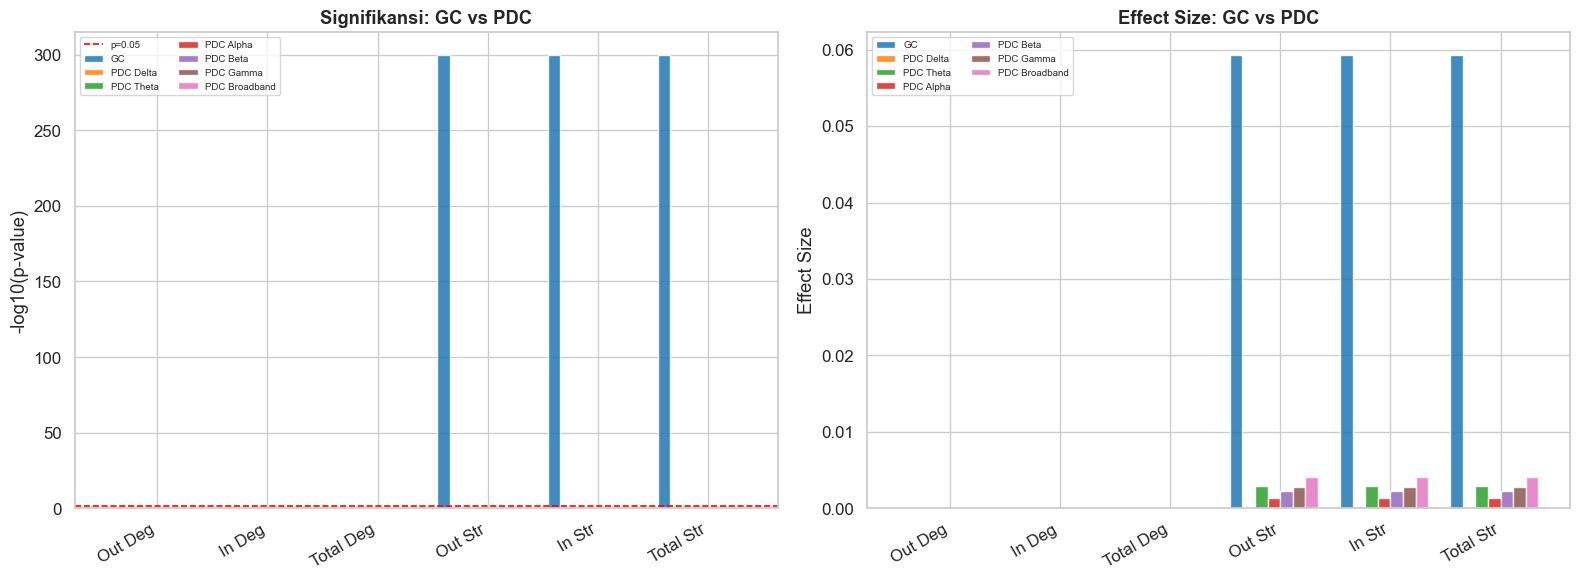

In [14]:
# ============================================================
# SEL INI: BAR CHART -log10(p) DAN EFFECT SIZE
# ------------------------------------------------------------
# Membuat 2 bar chart berdampingan:
#   Kiri  : -log10(p-value) per metrik per metode
#            Garis merah putus-putus = ambang batas p=0.05
#   Kanan : Effect size per metrik per metode
#
# FIX: Warna dan lebar bar diatur DINAMIS sesuai jumlah metode
#      (sebelumnya asumsi 4 metode, sekarang mendukung 7+).
# FIX: Nilai NaN (zero variance) di-replace 0 agar tidak
#      merusak tampilan bar chart.
# Output: gc_vs_pdc_comparison_bars.png
# ============================================================
import matplotlib.cm as cm

method_names = list(all_results.keys())
n_methods    = len(method_names)
metrics      = [SHORT[c] for c in MEAN_COLS]
x            = np.arange(len(metrics))
# FIX: lebar bar dinamis agar semua muat
width        = 0.8 / n_methods
colors       = [cm.tab10(i/10) for i in range(n_methods)]

fig, axes = plt.subplots(1, 2, figsize=(max(16, n_methods*2), 6))

for i, name in enumerate(method_names):
    res = all_results[name]
    pvals   = [res[res['metric']==m]['test_p_value'].values[0] if not res[res['metric']==m].empty else np.nan for m in metrics]
    effects = [res[res['metric']==m]['effect_size'].values[0]  if not res[res['metric']==m].empty else np.nan for m in metrics]
    # FIX: replace NaN dengan 0 agar bar tidak error
    neg_log = [-np.log10(max(p, 1e-300)) if not np.isnan(p) else 0.0 for p in pvals]
    eff_vals= [e if not np.isnan(e) else 0.0 for e in effects]

    axes[0].bar(x + i*width, neg_log,  width, label=name, color=colors[i], alpha=0.85)
    axes[1].bar(x + i*width, eff_vals, width, label=name, color=colors[i], alpha=0.85)

center = width * n_methods / 2
axes[0].axhline(y=-np.log10(0.05), color='red', linestyle='--', linewidth=1.2, label='p=0.05')
axes[0].set_xticks(x + center); axes[0].set_xticklabels(metrics, rotation=30, ha='right')
axes[0].set_ylabel('-log10(p-value)'); axes[0].set_title('Signifikansi: GC vs PDC', fontweight='bold')
axes[0].legend(fontsize=7, ncol=2)

axes[1].set_xticks(x + center); axes[1].set_xticklabels(metrics, rotation=30, ha='right')
axes[1].set_ylabel('Effect Size'); axes[1].set_title('Effect Size: GC vs PDC', fontweight='bold')
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
p = FIG_DIR / 'gc_vs_pdc_comparison_bars.png'
fig.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved: {p}')
plt.show()


---
## 6. Heatmap Signifikansi & Effect Size

Dua heatmap: p-value (kiri) dan effect size (kanan) untuk semua kombinasi metrik × metode.

Saved: D:\Skripsi\new_data\phase_2_statistics\2.4_gc_vs_pdc_comparison\figures\gc_vs_pdc_heatmap.png


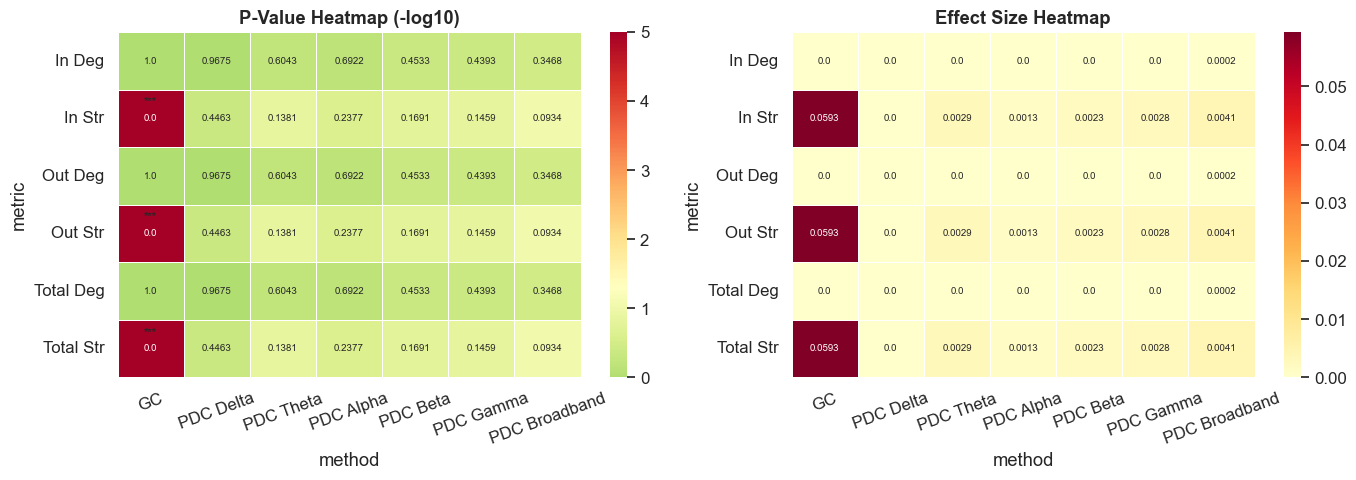

In [15]:
# ============================================================
# SEL INI: HEATMAP P-VALUE DAN EFFECT SIZE
# ------------------------------------------------------------
# Membuat 2 heatmap berdampingan:
#   Kiri  : -log10(p-value) — semakin merah = semakin signifikan
#   Kanan : Effect size — semakin gelap = pengaruh lebih besar
# Nilai NaN (metrik zero-variance) ditampilkan sebagai sel kosong.
#
# FIX: Menggunakan pivot_table() (bukan pivot()) untuk menghindari
#      error 'Index contains duplicate entries' jika ada data duplikat.
# FIX: Tanda bintang (* ** ***) ditambahkan otomatis ke sel
#      yang signifikan berdasarkan p-value asli.
# Output: gc_vs_pdc_heatmap.png
# ============================================================
heat_rows = []
for name, res in all_results.items():
    for _, row in res.iterrows():
        heat_rows.append({
            'method'     : name,
            'metric'     : row['metric'],
            'p_value'    : row['test_p_value'],
            'effect_size': row['effect_size'],
        })

heat_df = pd.DataFrame(heat_rows)

# FIX: pivot_table (bukan pivot) untuk keamanan
method_order = list(all_results.keys())
pivot_p = heat_df.pivot_table(index='metric', columns='method', values='p_value',    aggfunc='first')[method_order]
pivot_e = heat_df.pivot_table(index='metric', columns='method', values='effect_size', aggfunc='first')[method_order]

log_p = -np.log10(pivot_p.clip(lower=1e-10))

fig, axes = plt.subplots(1, 2, figsize=(max(14, len(method_order)*2), 5))

# Heatmap 1: p-value
sns.heatmap(log_p, annot=pivot_p.round(4).astype(str), fmt='',
            cmap='RdYlGn_r', linewidths=0.5, ax=axes[0],
            vmin=0, vmax=5, center=-np.log10(0.05),
            annot_kws={'size':7})
axes[0].set_title('P-Value Heatmap (-log10)', fontweight='bold')
axes[0].tick_params(axis='y', rotation=0)
axes[0].tick_params(axis='x', rotation=20)

# Tambah tanda bintang
for i, metric in enumerate(pivot_p.index):
    for j, method in enumerate(pivot_p.columns):
        p = pivot_p.loc[metric, method]
        if pd.isna(p): continue
        stars = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
        if stars:
            axes[0].text(j+0.5, i+0.2, stars, ha='center', va='center', fontsize=8, fontweight='bold')

# Heatmap 2: effect size
sns.heatmap(pivot_e, annot=pivot_e.round(4).astype(str), fmt='',
            cmap='YlOrRd', linewidths=0.5, ax=axes[1],
            annot_kws={'size':7})
axes[1].set_title('Effect Size Heatmap', fontweight='bold')
axes[1].tick_params(axis='y', rotation=0)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
p = FIG_DIR / 'gc_vs_pdc_heatmap.png'
fig.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved: {p}')
plt.show()


---
## 7. Ringkasan & Kesimpulan

In [16]:
# ============================================================
# SEL INI: RINGKASAN AKHIR PHASE 2.4
# ------------------------------------------------------------
# Menampilkan ringkasan kompetitif: berapa kali GC dan
# masing-masing band PDC 'menang' dalam hal signifikansi (p)
# dan kekuatan efek (effect size).
# Ini langsung menjawab pertanyaan utama penelitian:
#   'Metode konektivitas mana yang paling baik membedakan emosi?'
# Informasi ini masuk ke Bab 4 (Hasil) skripsi.
# ============================================================
print('='*65)
print('PHASE 2.4 COMPLETE — GC vs PDC Comparison')
print('='*65)

print('\n--- PEMENANG PER METRIK ---')
print(f'  {"Metric":<12} {"Winner p-value":<20} {"Winner Effect Size"}')
print('  '+'-'*50)
for _, row in comp_df.iterrows():
    print(f'  {row["metric"]:<12} {row["winner_p"]:<20} {row["winner_effect"]}')

print(f'\n--- TOTAL KEMENANGAN ---')
print('  [P-Value Wins]')
for name, count in p_wins.items():
    bar = '█' * count
    print(f'    {name:<18} {count} {bar}')
print('  [Effect Size Wins]')
for name, count in e_wins.items():
    bar = '█' * count
    print(f'    {name:<18} {count} {bar}')

print(f'\n--- FILE OUTPUT ---')
for f in sorted(OUTPUT_DIR.glob('*.csv')):
    print(f'  {f.name}')
print('--- FIGURES ---')
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  {f.name}')


PHASE 2.4 COMPLETE — GC vs PDC Comparison

--- PEMENANG PER METRIK ---
  Metric       Winner p-value       Winner Effect Size
  --------------------------------------------------
  Out Deg      PDC Broadband        PDC Broadband
  In Deg       PDC Broadband        PDC Broadband
  Total Deg    PDC Broadband        PDC Broadband
  Out Str      GC                   GC
  In Str       GC                   GC
  Total Str    GC                   GC

--- TOTAL KEMENANGAN ---
  [P-Value Wins]
    PDC Broadband      3 ███
    GC                 3 ███
  [Effect Size Wins]
    PDC Broadband      3 ███
    GC                 3 ███

--- FILE OUTPUT ---
  descriptive_gc.csv
  descriptive_pdc_alpha.csv
  descriptive_pdc_beta.csv
  descriptive_pdc_broadband.csv
  descriptive_pdc_delta.csv
  descriptive_pdc_gamma.csv
  descriptive_pdc_theta.csv
  gc_vs_pdc_comparison_table.csv
  inferential_gc.csv
  inferential_pdc_alpha.csv
  inferential_pdc_beta.csv
  inferential_pdc_broadband.csv
  inferential_pdc_de